In [16]:
import json
import os

def load_and_filter_edges(file_path, limit=50):
    """
    Load edges from a JSON file and filter the longest edges.

    Args:
        file_path (str): Path to the JSON file containing edges.
        limit (int): Maximum number of edges to keep based on length.

    Returns:
        list: A list of the longest edges.
    """
    # Load edges from the JSON file
    with open(file_path, 'r') as file:
        edges = json.load(file)

    # Sort edges by length in descending order and keep the top `limit` edges
    filtered_edges = sorted(edges, key=lambda edge: edge["length"], reverse=True)[:limit]

    return filtered_edges

def main():
    # File paths for the JSON files
    edges_to_approximate_file = "output_folder_for_edges/muhammed_edges.json"  # Replace with your file path
    edges_to_use_file = "output_folder_for_edges/pepsi_edges.json"  # Replace with your file path

    # Ensure the files exist
    if not os.path.exists(edges_to_approximate_file):
        print(f"File not found: {edges_to_approximate_file}")
        return
    if not os.path.exists(edges_to_use_file):
        print(f"File not found: {edges_to_use_file}")
        return

    # Load and filter the edges
    edges_to_approximate = load_and_filter_edges(edges_to_approximate_file, limit=50)
    edges_to_use = load_and_filter_edges(edges_to_use_file, limit=50)

    # Print summary
    print(f"Loaded {len(edges_to_approximate)} edges to approximate from {edges_to_approximate_file}.")
    print(f"Loaded {len(edges_to_use)} edges to use from {edges_to_use_file}.")

    # Save the filtered edges to new JSON files for verification
    with open("filtered_edges_to_approximate.json", 'w') as file:
        json.dump(edges_to_approximate, file, indent=4)
    with open("filtered_edges_to_use.json", 'w') as file:
        json.dump(edges_to_use, file, indent=4)

    print("Filtered edges saved to 'filtered_edges_to_approximate.json' and 'filtered_edges_to_use.json'.")

if __name__ == "__main__":
    main()

Loaded 50 edges to approximate from output_folder_for_edges/muhammed_edges.json.
Loaded 50 edges to use from output_folder_for_edges/pepsi_edges.json.
Filtered edges saved to 'filtered_edges_to_approximate.json' and 'filtered_edges_to_use.json'.


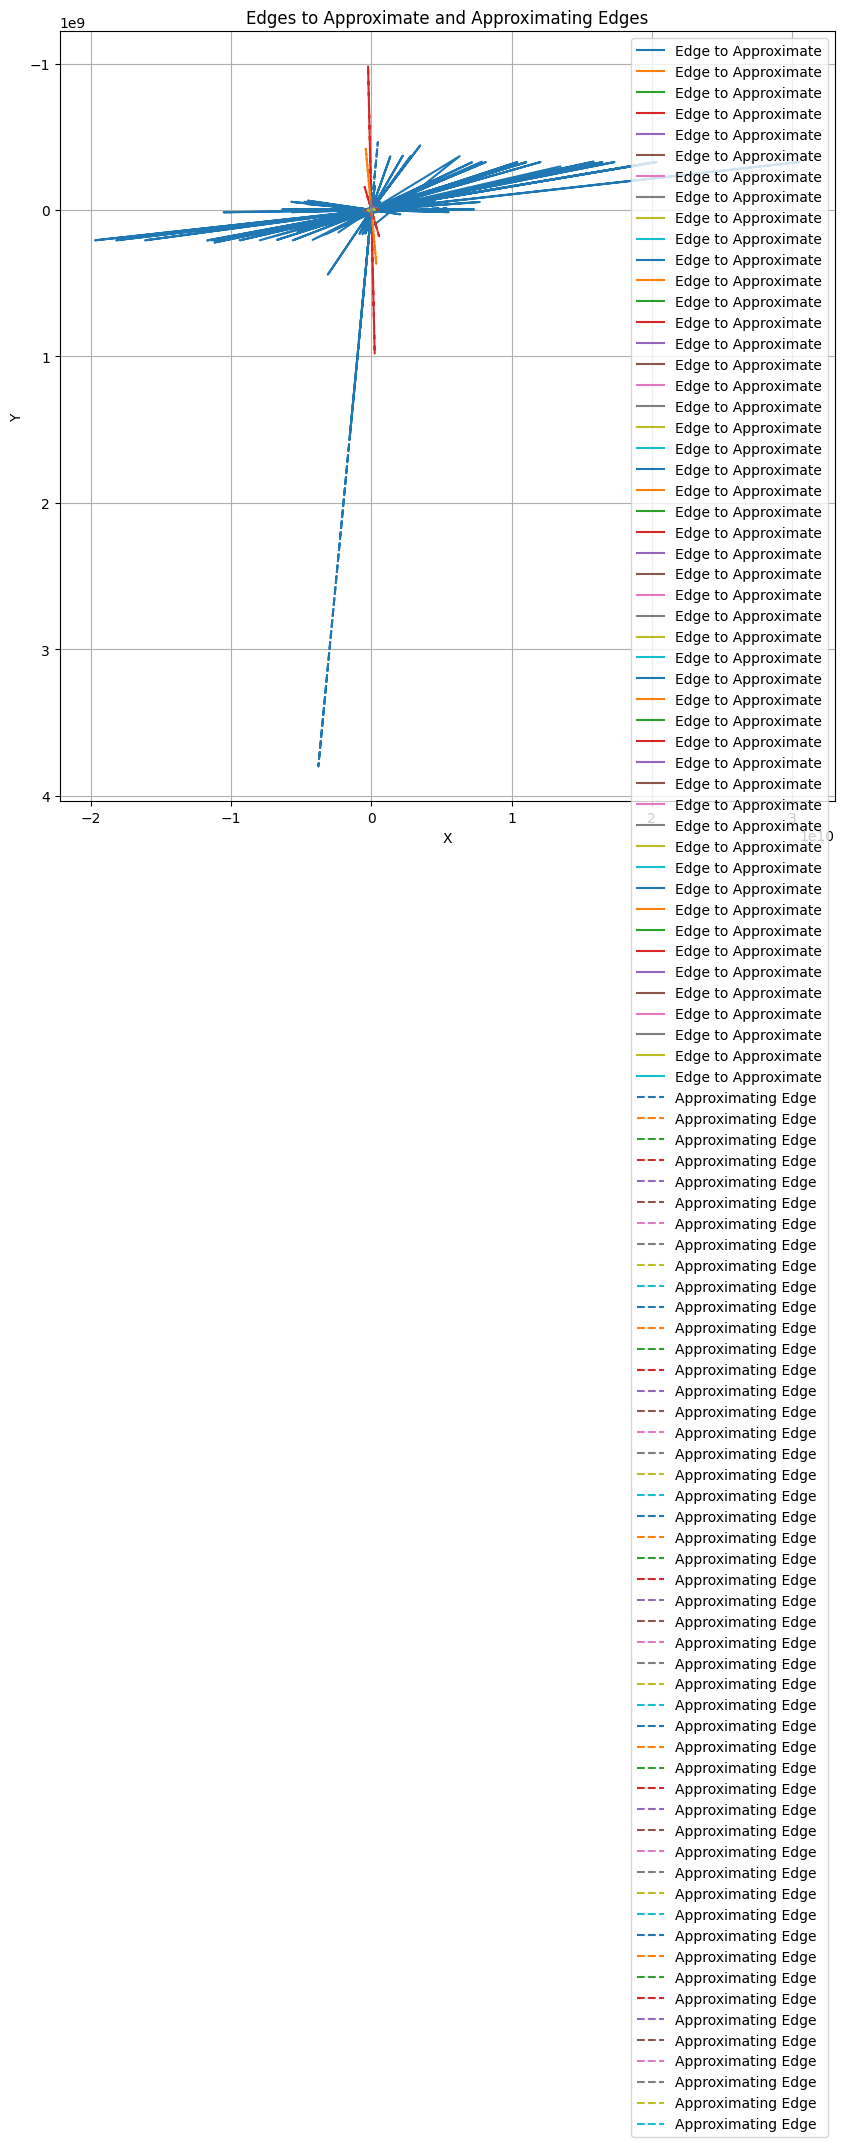

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

# Load the filtered edges
with open("filtered_edges_to_approximate.json", "r") as file:
    edges_to_approximate = json.load(file)

with open("filtered_edges_to_use.json", "r") as file:
    edges_to_use = json.load(file)

def evaluate_spline(spline_coefficients, t):
    """
    Evaluate a cubic spline at parameter t.

    Args:
        spline_coefficients (list): Coefficients of the cubic spline segments.
        t (numpy.ndarray): Parameter values to evaluate.

    Returns:
        numpy.ndarray: Evaluated spline values.
    """
    # Ensure t is a numpy array
    t = np.asarray(t)

    # Number of spline segments
    num_segments = len(spline_coefficients[0])

    # Initialize the result array
    result = np.zeros_like(t)

    # Evaluate each segment
    for i in range(num_segments):
        # Find the indices of t values in the current segment
        segment_mask = (t >= i / num_segments) & (t < (i + 1) / num_segments)

        # Normalize t values to the range [0, 1] for the current segment
        t_segment = (t[segment_mask] - i / num_segments) * num_segments

        # Evaluate the cubic polynomial for the current segment
        c3, c2, c1, c0 = spline_coefficients[:, i]
        result[segment_mask] = c3 * t_segment**3 + c2 * t_segment**2 + c1 * t_segment + c0

    # Handle the last segment (t == 1)
    if t[-1] == 1:
        c3, c2, c1, c0 = spline_coefficients[:, -1]
        result[-1] = c3 * 1**3 + c2 * 1**2 + c1 * 1 + c0

    return result

# Function to transform an edge (translate and rotate)
def transform_edge(edge, translation, rotation_angle):
    t = np.array(edge["parametric"]["t"])
    x_t = np.array(edge["parametric"]["x_t"])
    y_t = np.array(edge["parametric"]["y_t"])

    # Evaluate the spline at t
    x_coords = evaluate_spline(x_t, t)
    y_coords = evaluate_spline(y_t, t)

    # Apply rotation
    theta = np.radians(rotation_angle)
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    rotated_coords = np.dot(rotation_matrix, np.vstack((x_coords, y_coords)))

    # Apply translation
    translated_coords = rotated_coords + np.array(translation).reshape(2, 1)

    return translated_coords[0], translated_coords[1]

# Function to compute the fitness of a transformation
def compute_fitness(approximated_x, approximated_y, used_x, used_y):
    # Compute the distance between the approximated edge and the used edge
    approximated_points = np.column_stack((approximated_x, approximated_y))
    used_points = np.column_stack((used_x, used_y))
    distances = cdist(approximated_points, used_points)

    # Minimize the mean distance and maximize the overlap
    mean_distance = np.mean(np.min(distances, axis=1))
    overlap = np.sum(np.min(distances, axis=1) < 1.0)  # Count points within a threshold distance
    return mean_distance - overlap  # Lower is better

# Plot the edges to be approximated
plt.figure(figsize=(10, 10))
for edge in edges_to_approximate:
    t = np.array(edge["parametric"]["t"])
    x_t = np.array(edge["parametric"]["x_t"])
    y_t = np.array(edge["parametric"]["y_t"])
    x_coords = evaluate_spline(x_t, t)
    y_coords = evaluate_spline(y_t, t)
    plt.plot(x_coords, y_coords, label="Edge to Approximate")

# Loop through each edge to approximate
for approximated_edge in edges_to_approximate:
    t_approx = np.array(approximated_edge["parametric"]["t"])
    x_t_approx = np.array(approximated_edge["parametric"]["x_t"])
    y_t_approx = np.array(approximated_edge["parametric"]["y_t"])
    approximated_x = evaluate_spline(x_t_approx, t_approx)
    approximated_y = evaluate_spline(y_t_approx, t_approx)

    best_fitness = float("inf")
    best_combination = None

    # Loop through edges to use
    for used_edge in edges_to_use:
        # Optimize translation and rotation
        def objective(params):
            translation = params[:2]
            rotation_angle = params[2]
            used_x, used_y = transform_edge(used_edge, translation, rotation_angle)
            return compute_fitness(approximated_x, approximated_y, used_x, used_y)

        # Initial guess: no translation, no rotation
        initial_guess = [0, 0, 0]

        # Bounds for translation and rotation
        bounds = [(-100, 100), (-100, 100), (0, 360)]  # Adjust bounds as needed

        # Optimize
        result = minimize(objective, initial_guess, bounds=bounds)

        # Check if this is the best combination
        if result.fun < best_fitness:
            best_fitness = result.fun
            best_combination = (used_edge, result.x)

    # Apply the best transformation and plot the result
    if best_combination:
        best_edge, best_params = best_combination
        best_translation = best_params[:2]
        best_rotation = best_params[2]
        used_x, used_y = transform_edge(best_edge, best_translation, best_rotation)
        plt.plot(used_x, used_y, label="Approximating Edge", linestyle="--")

plt.legend()
plt.title("Edges to Approximate and Approximating Edges")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().invert_yaxis()  # Match image coordinate system
plt.grid()
plt.show()

In [18]:
def evaluate_spline(spline_coefficients, t):
    """
    Evaluate a cubic spline at parameter t.

    Args:
        spline_coefficients (list): Coefficients of the cubic spline segments.
        t (numpy.ndarray): Parameter values to evaluate.

    Returns:
        numpy.ndarray: Evaluated spline values.
    """
    # Ensure t is a numpy array
    t = np.asarray(t)

    # Convert spline_coefficients to a numpy array
    spline_coefficients = np.array(spline_coefficients)

    # Check the shape of spline_coefficients
    if spline_coefficients.shape[0] != 4:
        raise ValueError(f"Expected 4 rows in spline_coefficients, got {spline_coefficients.shape[0]}")

    # Number of spline segments
    num_segments = spline_coefficients.shape[1]

    # Initialize the result array
    result = np.zeros_like(t)

    # Evaluate each segment
    for i in range(num_segments):
        # Find the indices of t values in the current segment
        segment_mask = (t >= i / num_segments) & (t < (i + 1) / num_segments)

        # Normalize t values to the range [0, 1] for the current segment
        t_segment = (t[segment_mask] - i / num_segments) * num_segments

        # Evaluate the cubic polynomial for the current segment
        c3, c2, c1, c0 = spline_coefficients[:, i]
        result[segment_mask] = c3 * t_segment**3 + c2 * t_segment**2 + c1 * t_segment + c0

    # Handle the last segment (t == 1)
    if t[-1] == 1:
        c3, c2, c1, c0 = spline_coefficients[:, -1]
        result[-1] = c3 * 1**3 + c2 * 1**2 + c1 * 1 + c0

    return result

In [19]:
# Load the JSON file
json_file_path = "filtered_edges_to_use.json"  # Replace with your JSON file path
with open(json_file_path, "r") as file:
    edges = json.load(file)

# Plot the splines
plt.figure(figsize=(10, 10))
for edge in edges:
    t = np.array(edge["parametric"]["t"])
    x_t = np.array(edge["parametric"]["x_t"])
    y_t = np.array(edge["parametric"]["y_t"])
    x_coords = evaluate_spline(x_t, t)
    y_coords = evaluate_spline(y_t, t)

    # Preserve the location of the edge by adding its translation (if any)
    if "translation" in edge:
        x_coords += edge["translation"][0]
        y_coords += edge["translation"][1]

    plt.plot(x_coords, y_coords, label=f"Edge {edges.index(edge)}")

plt.title("Splines from JSON File (Preserving Location)")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().invert_yaxis()  # Match image coordinate system
plt.legend()
plt.grid()
plt.show()

ValueError: Expected 4 rows in spline_coefficients, got 2259

<Figure size 1000x1000 with 0 Axes>